# L05 · Logistic Regression, Softmax and Sparse Gene Signatures

*Companion notebook for Lecture 5 — Logistic Regression, Softmax, and Regularization (CS184A/284A, AI in Biology and Medicine).*

**Learning objectives**
1. Implement binary logistic regression with gradient descent and verify it against scikit-learn.
2. Interpret coefficients as log-odds / odds ratios — and see why they are conditional on the other features.
3. Fit softmax (multinomial) regression to classify five tumor types from gene expression.
4. Use an L1 penalty to select a sparse gene signature, choose λ by cross-validation, and test how stable the signature is.

Notation as in the slides: $n$ samples, $d$ features, $\mathbf X\in\mathbb R^{n\times d}$ (rows = samples), weights $\mathbf w$, bias $b$, loss $\mathcal L$, learning rate $\eta$, penalty strength $\lambda$; $y = 1$ = malignant.
Data splits, seeds and model settings follow `slides_src/lectures/L05_logistic_regression.py`, so the numbers match the slides.
Runtime: about 5 minutes on a 4-core laptop CPU (the L1 path on 2,000 genes is the slow part; no GPU needed).

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # course_utils.py lives in applications/
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from joblib import Parallel, delayed
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay
from course_utils import seed_everything, plot_style, load_tcga, PALETTE

warnings.filterwarnings("ignore", category=FutureWarning)
rng = seed_everything(0)
plot_style()
TYPES = ["BRCA", "COAD", "KIRC", "LUAD", "PRAD"]
TCOL = {t: PALETTE[i] for t, i in zip(TYPES, [0, 1, 2, 3, 5])}   # course tumor-type colors
N_JOBS = 4                                                         # parallel workers for the L1 fits

## 1. Datasets

**Breast biopsies (binary task).** Wisconsin Diagnostic Breast Cancer (Street, Wolberg & Mangasarian 1993; UCI Machine
Learning Repository, CC BY 4.0; bundled with scikit-learn). **One sample** = one fine-needle aspirate of a breast mass;
**input** = 30 summary statistics (mean, standard error, worst value) of 10 cell-nucleus measurements from a digitized
image (radius, texture, concavity, …); **target** $y=1$ malignant, $0$ benign (scikit-learn codes malignant as 0, so
we use `y = 1 - target`). Why it matters: a model whose weights can be read as odds ratios is easy to audit.

**TCGA tumors (5-class task).** UCI "gene expression cancer RNA-Seq" extract of The Cancer Genome Atlas PANCAN data
(Weinstein et al., *Nat. Genet.* 45, 1113 (2013); UCI, CC BY 4.0), loaded with `course_utils.load_tcga()` (cached from
L02). **One sample** = one tumor's RNA-seq profile, 20,531 genes (log-scale; gene names are anonymized in this extract);
**target** = tumor type (BRCA breast, COAD colon, KIRC kidney, LUAD lung, PRAD prostate). Why it matters: a short gene
list is cheaper to measure (a targeted panel) and easier to interpret than 20,531 genes.

In [2]:
bc = load_breast_cancer()
X, y = bc.data, 1 - bc.target
names = list(bc.feature_names)
Xg, yg, genes = load_tcga()
print(f"WDBC: n = {X.shape[0]} biopsies, d = {X.shape[1]} features, {y.sum()} malignant ({y.mean():.0%})")
print(f"TCGA: n = {Xg.shape[0]} tumors, d = {Xg.shape[1]:,} genes;", {str(t): int(c) for t, c in zip(*np.unique(yg, return_counts=True))})

WDBC: n = 569 biopsies, d = 30 features, 212 malignant (37%)
TCGA: n = 801 tumors, d = 20,531 genes; {'BRCA': 300, 'COAD': 78, 'KIRC': 146, 'LUAD': 141, 'PRAD': 136}


## 2. Exploration
A single nucleus feature already separates the classes fairly well; many features are strongly correlated (radius, perimeter and area measure the same thing).

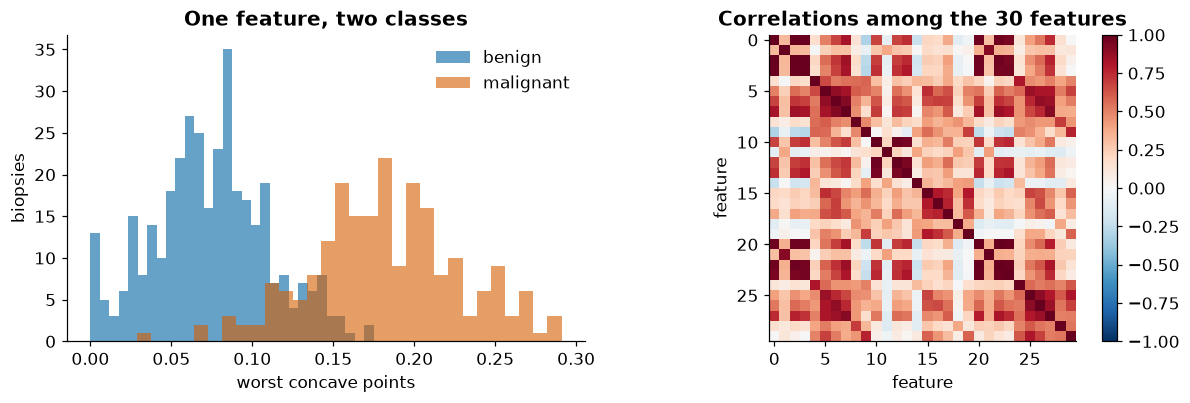

corr(mean radius, mean perimeter) = 0.998


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
j = names.index("worst concave points")
for k, (lab, col) in enumerate([("benign", PALETTE[0]), ("malignant", PALETTE[5])]):
    ax[0].hist(X[y == k, j], bins=30, alpha=0.6, color=col, label=lab)
ax[0].set(xlabel="worst concave points", ylabel="biopsies", title="One feature, two classes"); ax[0].legend()
Cm = np.corrcoef(X, rowvar=False)
im = ax[1].imshow(Cm, cmap="RdBu_r", vmin=-1, vmax=1)
ax[1].set(title="Correlations among the 30 features", xlabel="feature", ylabel="feature")
plt.colorbar(im, ax=ax[1], fraction=0.046); plt.tight_layout(); plt.show()
print("corr(mean radius, mean perimeter) =", Cm[names.index("mean radius"), names.index("mean perimeter")].round(3))

## 3. Preprocessing
Stratified 70/30 split (`random_state=0`), then standardize with statistics from the **training** biopsies only. With standardized features, a weight is the change in log-odds per one standard deviation.

In [4]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
sc = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)
print(f"{len(ytr)} training / {len(yte)} test biopsies")

398 training / 171 test biopsies


## 4. Model and training: logistic regression from scratch
Model $\hat y = \sigma(\mathbf w^\top\mathbf x + b)$; loss = mean binary cross-entropy $+\ \lambda\|\mathbf w\|^2$; gradient $\frac{1}{n}\mathbf X^\top(\hat{\mathbf y}-\mathbf y) + 2\lambda\mathbf w$.
scikit-learn minimizes $C\sum_i \ell_i + \tfrac12\|\mathbf w\|^2$, which is the same objective (times $nC$) when $\lambda = 1/(2nC)$. The slides use scikit-learn's default $C = 1$, so we use $\lambda = 1/(2n)$.

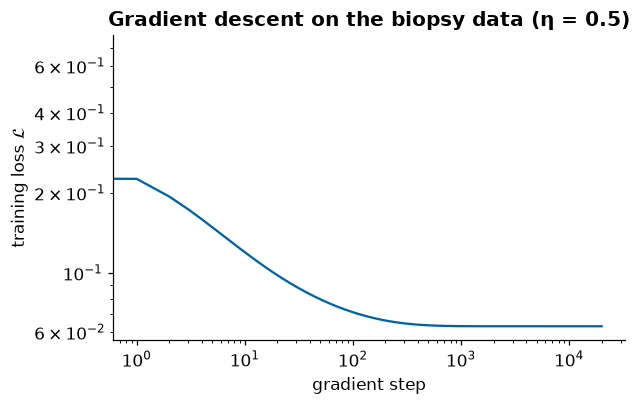

max |w_ours − w_sklearn| = 0.0052  (largest |w| = 1.25)


In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def bce(y, p, eps=1e-12):
    return -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

def fit_logistic(X, y, eta=0.5, steps=20000, lam=0.0):
    n, d = X.shape
    w, b = np.zeros(d), 0.0
    history = []
    for _ in range(steps):
        p = sigmoid(X @ w + b)
        grad_w = X.T @ (p - y) / n + 2 * lam * w      # L2 penalty lam * ||w||^2 (bias not penalized)
        grad_b = np.mean(p - y)
        w -= eta * grad_w; b -= eta * grad_b
        history.append(bce(y, p) + lam * w @ w)
    return w, b, history

C_WDBC = 1.0
lam = 1 / (2 * len(ytr) * C_WDBC)
w, b, hist = fit_logistic(Xtr_s, ytr, lam=lam)
plt.figure(figsize=(6, 3.6))
plt.plot(hist, color=PALETTE[0]); plt.xscale("log"); plt.yscale("log")
plt.xlabel("gradient step"); plt.ylabel("training loss $\\mathcal{L}$"); plt.title("Gradient descent on the biopsy data (η = 0.5)")
plt.show()

sk = LogisticRegression(C=C_WDBC, max_iter=5000).fit(Xtr_s, ytr)
print("max |w_ours − w_sklearn| =", f"{np.abs(w - sk.coef_[0]).max():.4f}", " (largest |w| =", f"{np.abs(w).max():.2f})")

## 5. Evaluation and odds ratios

In [6]:
acc_ours = np.mean((sigmoid(Xte_s @ w + b) > 0.5) == yte)
print(f"test accuracy: ours {acc_ours:.3f}, scikit-learn {sk.score(Xte_s, yte):.3f}")
order = np.argsort(-np.abs(sk.coef_[0]))[:6]
for j in order:
    wj = sk.coef_[0][j]
    print(f"{names[j]:25s} w = {wj:+.2f}   odds ratio per SD = {np.exp(wj):5.2f}")

test accuracy: ours 0.953, scikit-learn 0.953
radius error              w = +1.26   odds ratio per SD =  3.51
worst radius              w = +1.03   odds ratio per SD =  2.80
mean concave points       w = +0.94   odds ratio per SD =  2.57
worst symmetry            w = +0.94   odds ratio per SD =  2.56
compactness error         w = -0.93   odds ratio per SD =  0.39
perimeter error           w = +0.89   odds ratio per SD =  2.43


With standardized features, $e^{w_j}$ multiplies the odds of malignancy per one standard deviation of feature $j$ **holding the other features fixed**. Because the features are correlated, a coefficient can even change sign when the other features are added:

In [7]:
j = names.index("compactness error")
marg = LogisticRegression(C=C_WDBC, max_iter=5000).fit(Xtr_s[:, [j]], ytr).coef_[0][0]
print(f"compactness error: odds ratio {np.exp(marg):.1f} alone, but {np.exp(sk.coef_[0][j]):.2f} with the other 29 features")

compactness error: odds ratio 2.1 alone, but 0.39 with the other 29 features


## 6. Softmax regression: five tumor types from gene expression
**Preprocessing.** Same 70/30 stratified split idea (`random_state=0`), then keep the 2,000 most variable genes — **computed on the training tumors only** — and standardize them. (Set `SELECT_ON_ALL = True` for the leakage experiment in *Try it yourself*.)

**Model.** Softmax regression $\hat{\mathbf y} = \mathrm{softmax}(\mathbf W\mathbf x + \mathbf b)$ with 5 classes; here with an L2 penalty.

560 training / 241 test tumors, 2000 candidate genes
softmax (L2) test accuracy: 1.0
W has shape (5, 2000) (classes × genes); nonzero entries: 10000


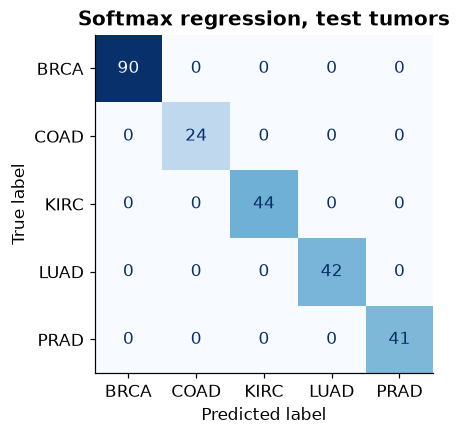

In [8]:
SELECT_ON_ALL = False      # Try it yourself: True = choose the genes using ALL tumors before splitting

Gtr, Gte, gtr, gte = train_test_split(Xg, yg, test_size=0.3, random_state=0, stratify=yg)
top = np.argsort(-(Xg if SELECT_ON_ALL else Gtr).var(0))[:2000]
scg = StandardScaler().fit(Gtr[:, top])
A, B = scg.transform(Gtr[:, top]), scg.transform(Gte[:, top])
print(f"{len(gtr)} training / {len(gte)} test tumors, {A.shape[1]} candidate genes")

soft = LogisticRegression(C=0.1, max_iter=3000).fit(A, gtr)       # L2-regularized softmax
print("softmax (L2) test accuracy:", round(soft.score(B, gte), 3))
print("W has shape", soft.coef_.shape, "(classes × genes); nonzero entries:", int((soft.coef_ != 0).sum()))
ConfusionMatrixDisplay.from_estimator(soft, B, gte, cmap="Blues", colorbar=False)
plt.title("Softmax regression, test tumors"); plt.show()

## 7. L1 regularization: a sparse gene signature
`LogisticRegression(l1_ratio=1, solver="saga")` minimizes $C\sum_i\ell_i + \|\mathbf W\|_1$, so smaller `C` = stronger penalty ($\lambda = 1/(nC)$ for a mean loss). We trace the path over six values of `C` with 5-fold CV on the training tumors. The 36 fits are independent, so we run them on `N_JOBS` = 4 cores (about 3–4 minutes; saga is single-threaded).

C = 0.005  genes selected =    5   CV accuracy = 0.375
C = 0.01   genes selected =   16   CV accuracy = 0.961
C = 0.02   genes selected =   26   CV accuracy = 0.995
C = 0.05   genes selected =   51   CV accuracy = 0.995
C = 0.1    genes selected =   77   CV accuracy = 0.995
C = 0.3    genes selected =  165   CV accuracy = 0.995


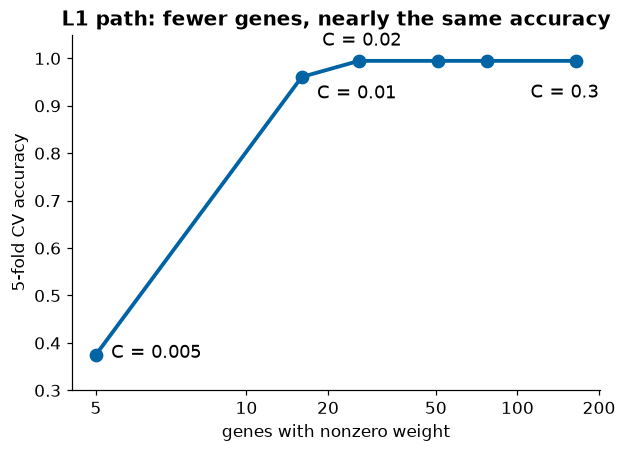

In [9]:
cv = StratifiedKFold(5, shuffle=True, random_state=0)
Cs = [0.005, 0.01, 0.02, 0.05, 0.1, 0.3]
folds = list(cv.split(A, gtr))

def l1_fit(C, tr_idx, l1_ratio=1.0):
    return LogisticRegression(l1_ratio=l1_ratio, C=C, solver="saga", max_iter=3000, tol=1e-3).fit(A[tr_idx], gtr[tr_idx])

def path_task(C, k):
    tr_idx = np.arange(len(gtr)) if k is None else folds[k][0]
    m = l1_fit(C, tr_idx)
    if k is None:                                        # full training set: count genes used
        return C, k, int((np.abs(m.coef_) > 0).any(0).sum())
    return C, k, m.score(A[folds[k][1]], gtr[folds[k][1]])

out = Parallel(n_jobs=N_JOBS)(delayed(path_task)(C, k) for C in Cs for k in [None, 0, 1, 2, 3, 4])
n_genes = {C: v for C, k, v in out if k is None}
cv_acc = {C: np.mean([v for C2, k, v in out if C2 == C and k is not None]) for C in Cs}
for C in Cs:
    print(f"C = {C:<6} genes selected = {n_genes[C]:4d}   CV accuracy = {cv_acc[C]:.3f}")

plt.figure(figsize=(6.2, 4.2))
plt.plot([n_genes[C] for C in Cs], [cv_acc[C] for C in Cs], "o-", color=PALETTE[0], lw=2.5, ms=8)
for C, off in {0.005: (10, -2), 0.01: (10, -14), 0.02: (-24, 10), 0.3: (-30, -24)}.items():
    plt.annotate(f"C = {C:g}", (n_genes[C], cv_acc[C]), textcoords="offset points", xytext=off, fontsize=12)
plt.xscale("symlog", linthresh=10); plt.xticks([5, 10, 20, 50, 100, 200], ["5", "10", "20", "50", "100", "200"])
plt.ylim(0.3, 1.05); plt.xlabel("genes with nonzero weight"); plt.ylabel("5-fold CV accuracy")
plt.title("L1 path: fewer genes, nearly the same accuracy"); plt.show()

*Note on reproducibility:* the saga solver visits the samples in a random order drawn from an unseeded generator, so
the gene counts of the weakly regularized fits can differ by a few genes between runs (the slide table shows 51 at
C = 0.05 and 165 at C = 0.3; runs of this notebook gave 51–52 and 164–168). CV accuracies, the chosen C = 0.02 model
(26 genes, test accuracy 0.992) and the stability numbers below were identical in every run.

We choose the smallest `C` (sparsest model) whose CV accuracy matches the best: **C = 0.02**. At C = 0.005 the model keeps too few genes to separate all five types. Refit on all training tumors and evaluate once on the test set.

In [10]:
C_best = 0.02
L1_RATIO = 1.0             # Try it yourself: 0 = pure L2, 0.5 = elastic net

lasso = LogisticRegression(l1_ratio=L1_RATIO, C=C_best, solver="saga", max_iter=3000, tol=1e-3).fit(A, gtr)
selected = np.where((np.abs(lasso.coef_) > 0).any(0))[0]
print(f"C = {C_best}, l1_ratio = {L1_RATIO}: {len(selected)} genes, test accuracy {lasso.score(B, gte):.3f}")
print("nonzero genes per tumor type:", {str(c): int((np.abs(lasso.coef_[k]) > 0).sum()) for k, c in enumerate(lasso.classes_)})

C = 0.02, l1_ratio = 1.0: 26 genes, test accuracy 0.992
nonzero genes per tumor type: {'BRCA': 7, 'COAD': 3, 'KIRC': 8, 'LUAD': 3, 'PRAD': 5}


### Is the signature stable?
Refit on 10 bootstrap resamples of the training tumors and compare the selected gene sets (Jaccard overlap = |intersection| / |union|).

signature sizes: [32, 26, 31, 23, 30, 26, 24, 27, 28, 24]
59 different genes ever chosen, only 10 in every fit; mean pairwise Jaccard = 0.54


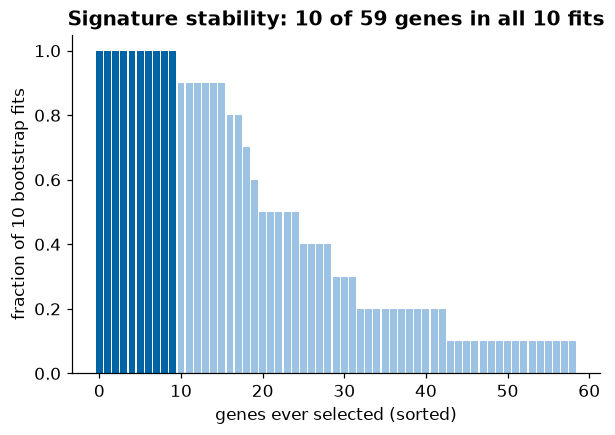

In [11]:
rb = np.random.default_rng(0)
boots = [rb.integers(0, len(gtr), len(gtr)) for _ in range(10)]
fits = Parallel(n_jobs=N_JOBS)(delayed(l1_fit)(C_best, idx, L1_RATIO) for idx in boots)
sets = [set(np.where((np.abs(m.coef_) > 0).any(0))[0]) for m in fits]
jac = [len(a & b) / len(a | b) for i, a in enumerate(sets) for b in sets[i + 1:]]
counts = np.bincount([g for s in sets for g in s], minlength=len(top))
n_ever, n_stable = int((counts > 0).sum()), int((counts == len(sets)).sum())
print(f"signature sizes: {[len(s) for s in sets]}")
print(f"{n_ever} different genes ever chosen, only {n_stable} in every fit; mean pairwise Jaccard = {np.mean(jac):.2f}")

freq = np.sort(counts[counts > 0])[::-1] / len(sets)
plt.figure(figsize=(6.2, 4))
plt.bar(range(len(freq)), freq, width=0.85, color=[PALETTE[0] if v >= 0.999 else "#9CC3E4" for v in freq])
plt.xlabel("genes ever selected (sorted)"); plt.ylabel("fraction of 10 bootstrap fits"); plt.ylim(0, 1.05)
plt.title(f"Signature stability: {n_stable} of {n_ever} genes in all 10 fits"); plt.show()

## 8. Visualization: what the signature reads out
Test-set expression of the selected genes, tumors grouped by type and genes grouped by the tumor type with the largest positive weight.

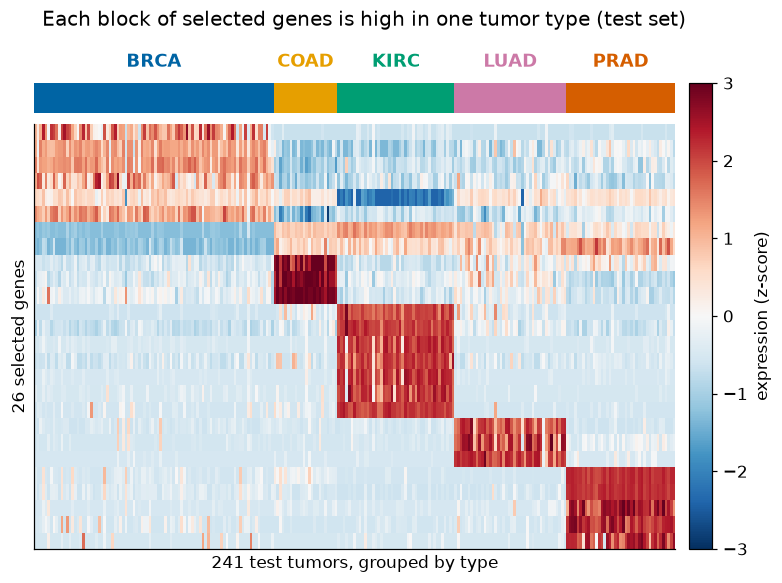

25 of 26 selected genes have an unselected partner with |r| > 0.8


In [12]:
owner = [str(lasso.classes_[k]) for k in lasso.coef_[:, selected].argmax(0)]
order = np.argsort([TYPES.index(t) for t in gte], kind="stable")
gorder = np.argsort([TYPES.index(t) for t in owner], kind="stable")
M = np.clip(B[order][:, selected[gorder]].T, -3, 3)
fig, (a0, a1) = plt.subplots(2, 1, figsize=(8, 5.5), gridspec_kw=dict(height_ratios=[0.07, 1], hspace=0.05))
yt = gte[order]
a0.imshow(np.array([[TYPES.index(t) for t in yt]]), aspect="auto", cmap=ListedColormap([TCOL[t] for t in TYPES]),
          vmin=-0.5, vmax=4.5, interpolation="nearest")
a0.set_axis_off()
for t in TYPES:
    a0.text(np.where(yt == t)[0].mean(), -0.9, t, ha="center", va="bottom", fontsize=12, color=TCOL[t], fontweight="bold")
im = a1.imshow(M, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3, interpolation="nearest")
a1.set_xticks([]); a1.set_yticks([])
a1.set_xlabel(f"{len(yt)} test tumors, grouped by type"); a1.set_ylabel(f"{M.shape[0]} selected genes")
fig.colorbar(im, ax=[a0, a1], fraction=0.04, pad=0.02).set_label("expression (z-score)")
fig.suptitle("Each block of selected genes is high in one tumor type (test set)", y=1.0)
plt.show()

# each selected gene's strongest correlation with an UNselected candidate gene (training tumors)
uns = np.setdiff1d(np.arange(len(top)), selected)
R = np.corrcoef(A[:, selected].T, A[:, uns].T)[:len(selected), len(selected):]
print(f"{int((np.abs(R).max(1) > 0.8).sum())} of {len(selected)} selected genes have an unselected partner with |r| > 0.8")

## 9. Biological interpretation
- A few dozen genes classify these five tumor types almost perfectly: each block of genes in the heat map is high in one tissue, so the signature reads out **tissue of origin** — predictive, not necessarily causal for the cancer.
- The exact gene list changes from resample to resample, and most selected genes have a highly correlated unselected partner. Lasso picks one representative among correlated genes, so a signature is **one** of many equally predictive lists, not the set of "important" genes.
- Gene names are anonymized in this extract. With real annotations, one would compare the selected genes with known tissue markers and validate the panel on independent cohorts, platforms and labs.

## 10. Try it yourself
From the lecture:
1. Use L2 instead of L1. How many genes have nonzero weight? (Set `L1_RATIO = 0` in Section 7.)
2. Try elastic net (`l1_ratio = 0.5`). Is the signature more stable? (Set `L1_RATIO = 0.5`; the bootstrap cell uses it too. Compare the Jaccard overlap and the number of genes; elastic net keeps more genes at the same `C`.)
3. Select genes on ALL data before splitting. What happens to test accuracy? (Set `SELECT_ON_ALL = True` in Section 6 and rerun. The variance filter ignores labels, so the leak is mild; why would selecting genes by their correlation with the tumor type be much worse? See Lecture 6.)

More:
4. Refit the biopsy model with `C_WDBC = 0.01` and `C_WDBC = 100`. How do the odds ratios and the test accuracy change?
5. *(CS284A)* Add Newton's method to `fit_logistic` using the Hessian $\frac1n\mathbf X^\top\mathbf S\mathbf X + 2\lambda\mathbf I$, $\mathbf S = \mathrm{diag}(\hat y_i(1-\hat y_i))$. How many iterations does it need compared with 20,000 gradient steps?